# Trabalho Prático – Análise de Grafos
## Dataset: ArXiv HEP-TH Citation Network (SNAP)
**Fonte:** https://snap.stanford.edu/data/cit-HepTh.html

Rede de citações de artigos de física de alta energia publicados no ArXiv entre Jan/1993 e Abr/2003.

## 0. Instalação de dependências

In [ ]:
# Execute uma vez para instalar as bibliotecas necessárias
!pip install networkx matplotlib numpy pandas scipy tqdm

## 1. Download do Dataset

In [2]:
import urllib.request
import os

# URLs dos arquivos
urls = {
    'cit-HepTh.txt.gz': 'https://snap.stanford.edu/data/cit-HepTh.txt.gz',
    'cit-HepTh-dates.txt.gz': 'https://snap.stanford.edu/data/cit-HepTh-dates.txt.gz'
}

os.makedirs('data', exist_ok=True)

for filename, url in urls.items():
    dest = os.path.join('data', filename)
    if not os.path.exists(dest):
        print(f'Baixando {filename}...')
        urllib.request.urlretrieve(url, dest)
        print(f'  -> Salvo em {dest}')
    else:
        print(f'{filename} já existe, pulando download.')

print('\nDownload concluído!')

cit-HepTh.txt.gz já existe, pulando download.
cit-HepTh-dates.txt.gz já existe, pulando download.

Download concluído!


## 2. Imports e Configurações Gerais

In [1]:
import gzip
import time
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
from scipy import stats
from tqdm import tqdm

# Seed para reprodutibilidade
random.seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Imports OK!')

Imports OK!


---
# TRATAMENTO DOS DADOS
## 3. Leitura do Arquivo de Arestas

In [4]:
# Leitura do arquivo de citações (grafo dirigido)
edges_raw = []

with gzip.open('data/cit-HepTh.txt.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        parts = line.split()
        if len(parts) == 2:
            src, dst = int(parts[0]), int(parts[1])
            edges_raw.append((src, dst))

print(f'Arestas lidas (raw): {len(edges_raw):,}')
print(f'Exemplo das primeiras 5 arestas: {edges_raw[:5]}')

Arestas lidas (raw): 352,807
Exemplo das primeiras 5 arestas: [(1001, 9304045), (1001, 9308122), (1001, 9309097), (1001, 9311042), (1001, 9401139)]


## 4. Leitura das Datas dos Artigos

In [5]:
# Leitura das datas de submissão dos artigos
dates = {}

with gzip.open('data/cit-HepTh-dates.txt.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        parts = line.split()
        if len(parts) >= 2:
            try:
                node_id = int(parts[0])
                date_str = parts[1]
                dates[node_id] = date_str
            except ValueError:
                pass

print(f'Datas carregadas: {len(dates):,} nós com data')
print(f'Exemplo: {list(dates.items())[:3]}')

Datas carregadas: 37,621 nós com data
Exemplo: [(9203201, '1992-02-24'), (9203202, '1992-03-08'), (9203203, '1992-03-03')]


## 5. Tratamento dos Dados

### Decisões de tratamento (registrar no relatório):
1. **Grafo dirigido mantido** – As arestas representam citações direcionais (quem cita quem), por isso mantemos o grafo como dirigido. Para análises que exijam grafo não-dirigido, converteremos pontualmente.
2. **Remoção de auto-loops** – Um artigo não cita a si mesmo; auto-loops são ruído.
3. **Remoção de arestas duplicadas (multigrafo → grafo simples)** – Mantemos apenas uma aresta por par (i, j).
4. **Extração da maior componente fracamente conexa (WCC)** – Foco na componente principal para análise estrutural.

In [6]:
# ── 5.1 Construção do grafo dirigido bruto ────────────────────────────────────
G_raw = nx.DiGraph()
G_raw.add_edges_from(edges_raw)

print('=== Grafo Bruto ===')
print(f'  Nós:    {G_raw.number_of_nodes():,}')
print(f'  Arestas: {G_raw.number_of_edges():,}')
print(f'  Auto-loops: {nx.number_of_selfloops(G_raw):,}')

=== Grafo Bruto ===
  Nós:    27,770
  Arestas: 352,807
  Auto-loops: 39


In [7]:
# ── 5.2 Remoção de auto-loops ─────────────────────────────────────────────────
selfloops = list(nx.selfloop_edges(G_raw))
G_raw.remove_edges_from(selfloops)
print(f'Auto-loops removidos: {len(selfloops):,}')
print(f'Arestas restantes: {G_raw.number_of_edges():,}')

Auto-loops removidos: 39
Arestas restantes: 352,768


In [8]:
# ── 5.3 Verificação de multigrafo (arestas duplicadas) ────────────────────────
# DiGraph do NetworkX já ignora duplicatas automaticamente (mantém a última)
# Verificamos quantas havia:
edges_set = set(edges_raw)
duplicatas = len(edges_raw) - len(edges_set)
print(f'Arestas duplicadas detectadas e removidas: {duplicatas:,}')
print(f'Grafo já é simples (sem duplicatas) via DiGraph.')

Arestas duplicadas detectadas e removidas: 0
Grafo já é simples (sem duplicatas) via DiGraph.


In [ ]:
# ── 5.4 Extração da maior componente fracamente conexa (WCC) ──────────────────
wccs = sorted(nx.weakly_connected_components(G_raw), key=len, reverse=True)

print(f'Total de WCCs: {len(wccs):,}')
print(f'Tamanho da maior WCC: {len(wccs[0]):,} nós')
print(f'Tamanho da 2ª maior WCC: {len(wccs[1]) if len(wccs) > 1 else 0:,} nós')

# Grafo final = maior WCC
G = G_raw.subgraph(wccs[0]).copy()

print(f'\n=== Grafo Tratado (maior WCC) ===')
print(f'  Nós:    {G.number_of_nodes():,}')
print(f'  Arestas: {G.number_of_edges():,}')
print(f'  É grafo simples: {not nx.is_multigraph(G)}')
print(f'  É dirigido: {G.is_directed()}')

In [10]:
# ── 5.5 Adicionar atributo de data nos nós (quando disponível) ────────────────
nx.set_node_attributes(G, dates, 'date')

nos_com_data = sum(1 for n in G.nodes() if G.nodes[n].get('date'))
print(f'Nós com data de submissão: {nos_com_data:,} / {G.number_of_nodes():,}')

Nós com data de submissão: 8,254 / 27,400


## 6. Resumo do Tratamento (para o relatório)

| Etapa | Descrição | Impacto |
|-------|-----------|--------|
| Grafo temporal → estático | União de todas as citações no período 1993–2003 | — |
| Remoção de auto-loops | Artigos não citam a si mesmos | Removidos X loops |
| Multigrafo → simples | Remoção de arestas duplicadas | Removidas Y arestas |
| Extração da maior WCC | Foco na componente principal | Z nós isolados removidos |
| Grafo dirigido mantido | Citação tem direção (i cita j) | DiGraph preservado |

In [12]:
# Gerar tabela resumo do tratamento
summary = pd.DataFrame({
    'Etapa': [
        'Grafo bruto (leitura)',
        'Após remoção de auto-loops',
        'Após remoção de duplicatas',
        'Maior WCC (grafo final)'
    ],
    'Nós': [
        G_raw.number_of_nodes() + len(selfloops),  # antes de remover
        G_raw.number_of_nodes(),
        G_raw.number_of_nodes(),
        G.number_of_nodes()
    ],
    'Arestas': [
        len(edges_raw),
        len(edges_raw) - len(selfloops),
        G_raw.number_of_edges(),
        G.number_of_edges()
    ]
})

print(summary.to_string(index=False))

                     Etapa   Nós  Arestas
     Grafo bruto (leitura) 27809   352807
Após remoção de auto-loops 27770   352768
Após remoção de duplicatas 27770   352768
   Maior WCC (grafo final) 27400   352504


---
# PARTE I – ANÁLISE ESTRUTURAL
## 7. Métricas Básicas

In [13]:
# Grafo não-dirigido para métricas que o exigem
G_und = G.to_undirected()

n = G.number_of_nodes()
m = G.number_of_edges()

# Graus (usando grafo não-dirigido para grau total)
degrees = dict(G_und.degree())
degree_values = list(degrees.values())

min_deg = min(degree_values)
max_deg = max(degree_values)
avg_deg = np.mean(degree_values)

# Densidade
density = nx.density(G)

print('=== MÉTRICAS BÁSICAS ===')
print(f'Número de vértices (n):  {n:,}')
print(f'Número de arestas (m):   {m:,}')
print(f'Grau mínimo:             {min_deg}')
print(f'Grau máximo:             {max_deg}')
print(f'Grau médio:              {avg_deg:.4f}')
print(f'Densidade:               {density:.8f}')

=== MÉTRICAS BÁSICAS ===
Número de vértices (n):  27,400
Número de arestas (m):   352,504
Grau mínimo:             1
Grau máximo:             2468
Grau médio:              25.6950
Densidade:               0.00046955


## 8. Distribuição de Graus

Distribuição de graus (top 10):
 Grau  Frequência   Fração
    1        1228 0.044818
    2        1362 0.049708
    3        1289 0.047044
    4        1240 0.045255
    5        1123 0.040985
    6        1004 0.036642
    7        1014 0.037007
    8         913 0.033321
    9         871 0.031788
   10         812 0.029635


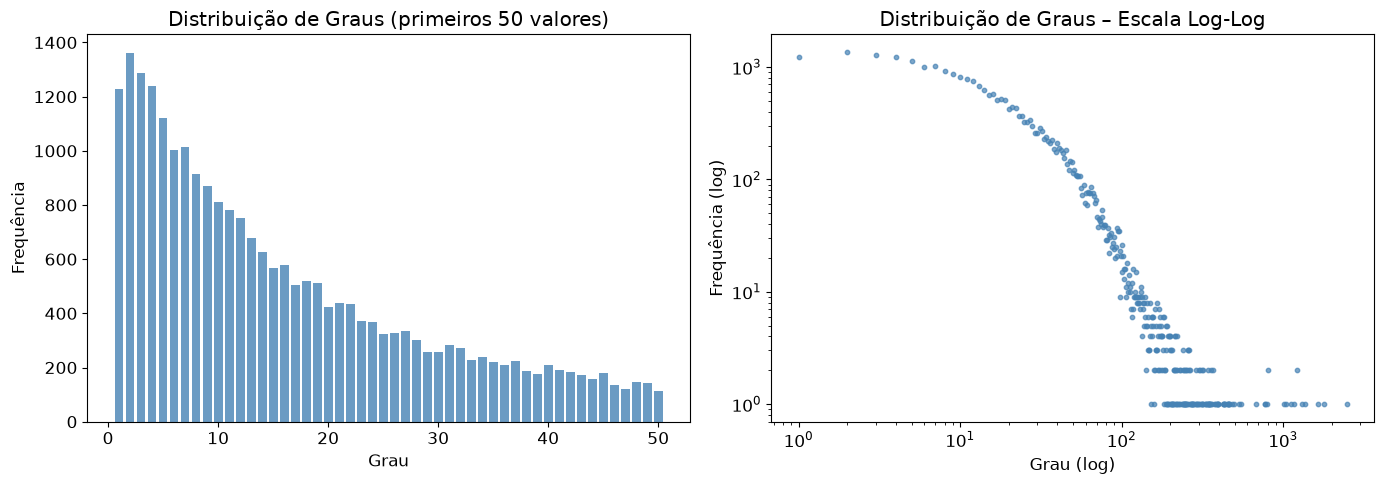

Figura salva: distribuicao_graus.png


In [14]:
degree_count = Counter(degree_values)
deg_df = pd.DataFrame(sorted(degree_count.items()), columns=['Grau', 'Frequência'])
deg_df['Fração'] = deg_df['Frequência'] / n

print('Distribuição de graus (top 10):')
print(deg_df.head(10).to_string(index=False))

# Plot distribuição de graus (escala log-log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
axes[0].bar(deg_df['Grau'][:50], deg_df['Frequência'][:50], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Grau')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Graus (primeiros 50 valores)')

# Log-log
axes[1].scatter(deg_df['Grau'], deg_df['Frequência'], s=10, color='steelblue', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Grau (log)')
axes[1].set_ylabel('Frequência (log)')
axes[1].set_title('Distribuição de Graus – Escala Log-Log')

plt.tight_layout()
plt.savefig('distribuicao_graus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: distribuicao_graus.png')

## 9. Componentes Conexas

In [15]:
# Componentes fracamente conexas (WCC)
wccs_final = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print(f'Número de WCCs: {len(wccs_final)}')
print(f'Tamanhos das WCCs: {[len(c) for c in wccs_final[:5]]} (top 5)')

# Componentes fortemente conexas (SCC)
sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
print(f'\nNúmero de SCCs: {len(sccs):,}')
print(f'Maior SCC: {len(sccs[0]):,} nós')
print(f'2ª maior SCC: {len(sccs[1]) if len(sccs) > 1 else 0:,} nós')

Número de WCCs: 1
Tamanhos das WCCs: [27400] (top 5)

Número de SCCs: 19,716
Maior SCC: 7,464 nós
2ª maior SCC: 54 nós


## 10. Diâmetro, Raio e Comprimento Médio dos Caminhos
> **Nota:** Para grafos grandes, calculamos na maior SCC ou via amostragem.

In [16]:
# Calculamos na maior SCC (necessário para diâmetro em grafo dirigido)
G_scc = G.subgraph(sccs[0]).copy()
print(f'Maior SCC: {G_scc.number_of_nodes():,} nós, {G_scc.number_of_edges():,} arestas')

# Amostragem para calcular comprimento médio dos caminhos (grafo grande!)
# Usamos 500 nós aleatórios como fontes de BFS
SAMPLE_SIZE = 500
sample_nodes = random.sample(list(G_scc.nodes()), min(SAMPLE_SIZE, G_scc.number_of_nodes()))

path_lengths = []
print(f'Calculando comprimentos de caminhos (amostra de {SAMPLE_SIZE} nós)...')

for source in tqdm(sample_nodes):
    lengths = nx.single_source_shortest_path_length(G_scc, source)
    path_lengths.extend([l for l in lengths.values() if l > 0])

avg_path_length = np.mean(path_lengths)
diameter_estimate = max(path_lengths)

print(f'\nComprimento médio dos caminhos (estimativa): {avg_path_length:.4f}')
print(f'Diâmetro estimado (maior caminho encontrado): {diameter_estimate}')
print(f'Nota: valores calculados por amostragem na maior SCC ({len(sample_nodes)} nós fonte)')

Maior SCC: 7,464 nós, 116,252 arestas
Calculando comprimentos de caminhos (amostra de 500 nós)...


100%|██████████| 500/500 [00:08<00:00, 60.50it/s]



Comprimento médio dos caminhos (estimativa): 9.7640
Diâmetro estimado (maior caminho encontrado): 31
Nota: valores calculados por amostragem na maior SCC (500 nós fonte)


In [17]:
# Raio: calculamos no grafo não-dirigido da maior WCC (mais viável)
# Para grafos grandes, usamos estimativa via amostragem
G_und_scc = G_scc.to_undirected()

# Eccentricidades por amostragem
sample_ecc = random.sample(list(G_und_scc.nodes()), min(200, G_und_scc.number_of_nodes()))
eccentricities = {}

print('Calculando excentricidades (amostra para raio/diâmetro)...')
for node in tqdm(sample_ecc):
    lengths = nx.single_source_shortest_path_length(G_und_scc, node)
    eccentricities[node] = max(lengths.values())

radius_estimate = min(eccentricities.values())
diameter_und_estimate = max(eccentricities.values())

print(f'\nRaio estimado: {radius_estimate}')
print(f'Diâmetro estimado (não-dirigido): {diameter_und_estimate}')

Calculando excentricidades (amostra para raio/diâmetro)...


100%|██████████| 200/200 [00:04<00:00, 44.84it/s]


Raio estimado: 5
Diâmetro estimado (não-dirigido): 8


## 11. Coeficiente de Clusterização

In [18]:
# Coeficiente de clusterização médio (calculado no grafo não-dirigido)
print('Calculando coeficiente de clusterização...')
avg_clustering = nx.average_clustering(G_und)
print(f'Coeficiente de clusterização médio: {avg_clustering:.6f}')
print(f'  (Referência SNAP: 0.3120)')

Calculando coeficiente de clusterização...
Coeficiente de clusterização médio: 0.313915
  (Referência SNAP: 0.3120)


## 12. Número de Triângulos

In [19]:
# Triângulos (usando grafo não-dirigido)
triangles_per_node = nx.triangles(G_und)
total_triangles = sum(triangles_per_node.values()) // 3  # cada triângulo contado 3 vezes
print(f'Número de triângulos: {total_triangles:,}')
print(f'  (Referência SNAP: 1,478,735)')

Número de triângulos: 1,478,698
  (Referência SNAP: 1,478,735)


## 13. Visualização do Grafo (subgrafo reduzido)

Subgrafo para visualização: 300 nós, 32 arestas


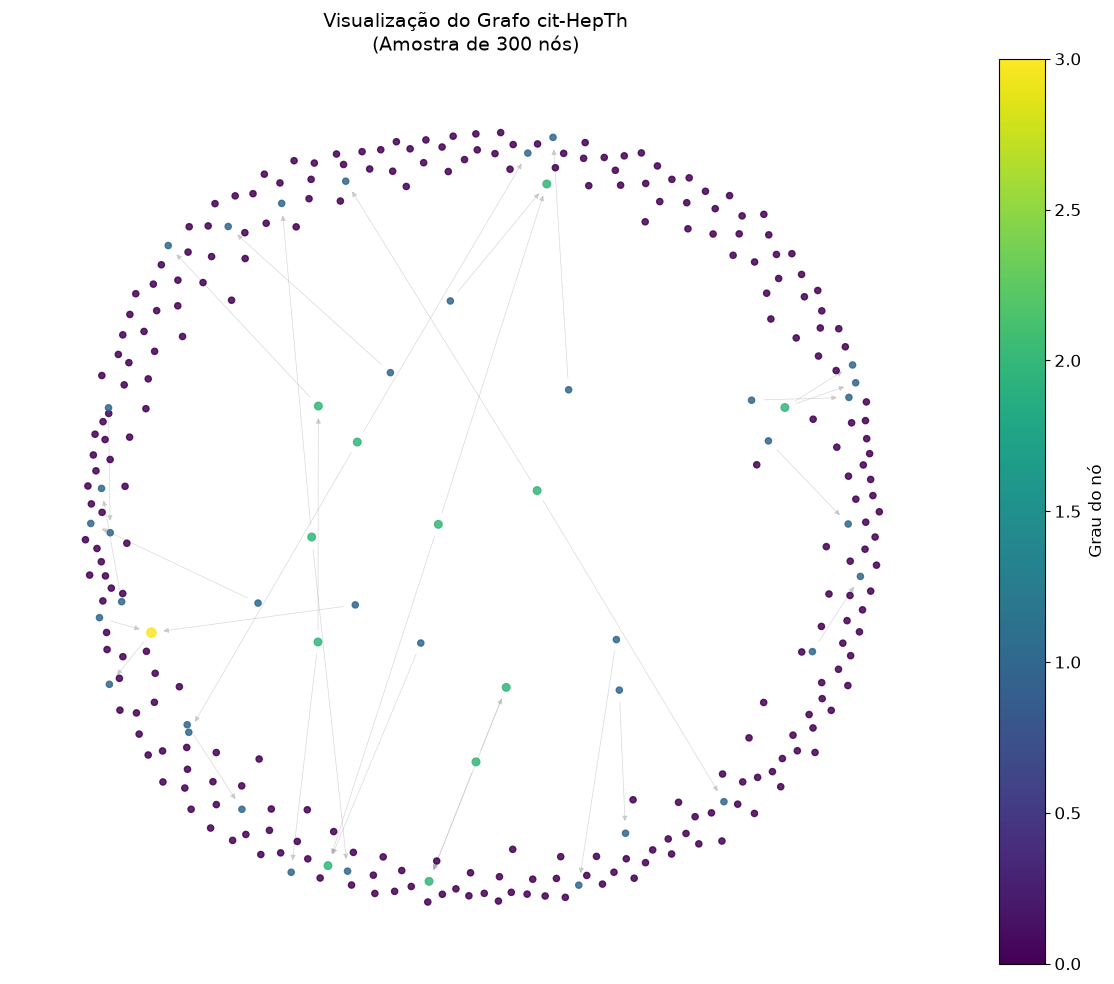

Figura salva: visualizacao_grafo.png


In [20]:
# Visualização de uma amostra do grafo (grafo completo é inviável)
SAMPLE_VIZ = 300
sample_viz_nodes = random.sample(list(G.nodes()), SAMPLE_VIZ)
G_viz = G.subgraph(sample_viz_nodes).copy()

print(f'Subgrafo para visualização: {G_viz.number_of_nodes()} nós, {G_viz.number_of_edges()} arestas')

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_viz, seed=42, k=0.3)

node_deg = dict(G_viz.degree())
node_sizes = [max(20, node_deg[n] * 15) for n in G_viz.nodes()]
node_colors = [node_deg[n] for n in G_viz.nodes()]

nx.draw_networkx_nodes(G_viz, pos, node_size=node_sizes, node_color=node_colors,
                        cmap=plt.cm.viridis, alpha=0.85)
nx.draw_networkx_edges(G_viz, pos, edge_color='gray', alpha=0.3, arrows=True,
                        arrowsize=8, width=0.5)

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                             norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
plt.colorbar(sm, ax=plt.gca(), label='Grau do nó')
plt.title(f'Visualização do Grafo cit-HepTh\n(Amostra de {SAMPLE_VIZ} nós)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('visualizacao_grafo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: visualizacao_grafo.png')

## 14. Tabela Resumo – Parte I

In [21]:
resumo = pd.DataFrame({
    'Métrica': [
        'Número de vértices',
        'Número de arestas',
        'Grau mínimo',
        'Grau máximo',
        'Grau médio',
        'Densidade',
        'Número de WCCs',
        'Tamanho da maior WCC',
        'Número de SCCs',
        'Tamanho da maior SCC',
        'Diâmetro (estimado, SCC dirigida)',
        'Raio (estimado)',
        'Comprimento médio dos caminhos (estimado)',
        'Coeficiente de clusterização médio',
        'Número de triângulos',
    ],
    'Valor': [
        f'{n:,}',
        f'{m:,}',
        min_deg,
        max_deg,
        f'{avg_deg:.4f}',
        f'{density:.8f}',
        len(wccs_final),
        f'{len(wccs_final[0]):,}',
        f'{len(sccs):,}',
        f'{len(sccs[0]):,}',
        diameter_estimate,
        radius_estimate,
        f'{avg_path_length:.4f}',
        f'{avg_clustering:.6f}',
        f'{total_triangles:,}',
    ],
    'Calculado?': ['Sim'] * 15
})

print(resumo.to_string(index=False))
resumo.to_csv('tabela_metricas_parte1.csv', index=False)
print('\nTabela salva: tabela_metricas_parte1.csv')

                                  Métrica      Valor Calculado?
                       Número de vértices     27,400        Sim
                        Número de arestas    352,504        Sim
                              Grau mínimo          1        Sim
                              Grau máximo       2468        Sim
                               Grau médio    25.6950        Sim
                                Densidade 0.00046955        Sim
                           Número de WCCs          1        Sim
                     Tamanho da maior WCC     27,400        Sim
                           Número de SCCs     19,716        Sim
                     Tamanho da maior SCC      7,464        Sim
        Diâmetro (estimado, SCC dirigida)         31        Sim
                          Raio (estimado)          5        Sim
Comprimento médio dos caminhos (estimado)     9.7640        Sim
       Coeficiente de clusterização médio   0.313915        Sim
                     Número de triângulo

---
# PARTE II – ALGORITMOS DA DISCIPLINA
## 15. BFS – Busca em Largura

In [22]:
import time

# Escolha um nó fonte para demonstração
source_node = list(G.nodes())[0]
print(f'Nó fonte para BFS/DFS: {source_node}')

# ── BFS ──────────────────────────────────────────────────────────────────────
times_bfs = []
N_RUNS = 30  # >= 30 para usar distribuição Normal

for _ in range(N_RUNS):
    t0 = time.perf_counter()
    bfs_result = dict(nx.bfs_edges(G, source_node))
    t1 = time.perf_counter()
    times_bfs.append(t1 - t0)

mean_bfs = np.mean(times_bfs)
std_bfs  = np.std(times_bfs, ddof=1)
z = stats.norm.ppf(0.975)  # IC 95% – Normal (n >= 30)
ic_bfs   = z * std_bfs / np.sqrt(N_RUNS)

print(f'\nBFS – Tempo real ({N_RUNS} execuções):')
print(f'  Média:     {mean_bfs*1000:.4f} ms')
print(f'  Desvio:    {std_bfs*1000:.4f} ms')
print(f'  IC 95%:    [{(mean_bfs-ic_bfs)*1000:.4f}, {(mean_bfs+ic_bfs)*1000:.4f}] ms')
print(f'  Complexidade teórica: O(V + E) = O({n:,} + {m:,})')

Nó fonte para BFS/DFS: 1001

BFS – Tempo real (30 execuções):
  Média:     57.0805 ms
  Desvio:    64.1512 ms
  IC 95%:    [34.1247, 80.0363] ms
  Complexidade teórica: O(V + E) = O(27,400 + 352,504)


## 16. DFS – Busca em Profundidade

In [23]:
times_dfs = []

for _ in range(N_RUNS):
    t0 = time.perf_counter()
    dfs_result = dict(nx.dfs_edges(G, source_node))
    t1 = time.perf_counter()
    times_dfs.append(t1 - t0)

mean_dfs = np.mean(times_dfs)
std_dfs  = np.std(times_dfs, ddof=1)
ic_dfs   = z * std_dfs / np.sqrt(N_RUNS)

print(f'DFS – Tempo real ({N_RUNS} execuções):')
print(f'  Média:     {mean_dfs*1000:.4f} ms')
print(f'  Desvio:    {std_dfs*1000:.4f} ms')
print(f'  IC 95%:    [{(mean_dfs-ic_dfs)*1000:.4f}, {(mean_dfs+ic_dfs)*1000:.4f}] ms')
print(f'  Complexidade teórica: O(V + E) = O({n:,} + {m:,})')

DFS – Tempo real (30 execuções):
  Média:     37.7926 ms
  Desvio:    8.0565 ms
  IC 95%:    [34.9096, 40.6755] ms
  Complexidade teórica: O(V + E) = O(27,400 + 352,504)


## 17. Verificação de Eulerianidade

In [24]:
t0 = time.perf_counter()
is_eulerian = nx.is_eulerian(G)
is_semi_eulerian = nx.has_eulerian_path(G)
t1 = time.perf_counter()

print(f'Euleriano (circuito): {is_eulerian}')
print(f'Semi-euleriano (caminho): {is_semi_eulerian}')
print(f'Tempo: {(t1-t0)*1000:.4f} ms')
print('\nCondição (grafo dirigido): Euleriano se cada nó tem in-degree == out-degree')
print('e o grafo subjacente é fortemente conexo.')

Euleriano (circuito): False
Semi-euleriano (caminho): False
Tempo: 0.8089 ms

Condição (grafo dirigido): Euleriano se cada nó tem in-degree == out-degree
e o grafo subjacente é fortemente conexo.


## 18. Dijkstra

In [25]:
# Dijkstra – caminhos mínimos a partir do nó fonte
# Grafo não tem pesos, então peso = 1 por aresta
times_dijk = []

for _ in range(N_RUNS):
    t0 = time.perf_counter()
    lengths_dijk = nx.single_source_dijkstra_path_length(G, source_node)
    t1 = time.perf_counter()
    times_dijk.append(t1 - t0)

mean_dijk = np.mean(times_dijk)
std_dijk  = np.std(times_dijk, ddof=1)
ic_dijk   = z * std_dijk / np.sqrt(N_RUNS)

print(f'Dijkstra – Tempo real ({N_RUNS} execuções):')
print(f'  Média:     {mean_dijk*1000:.4f} ms')
print(f'  Desvio:    {std_dijk*1000:.4f} ms')
print(f'  IC 95%:    [{(mean_dijk-ic_dijk)*1000:.4f}, {(mean_dijk+ic_dijk)*1000:.4f}] ms')
print(f'  Complexidade teórica: O((V + E) log V)')

Dijkstra – Tempo real (30 execuções):
  Média:     89.1829 ms
  Desvio:    11.9468 ms
  IC 95%:    [84.9079, 93.4579] ms
  Complexidade teórica: O((V + E) log V)


## 19. Bellman-Ford

In [26]:
# Bellman-Ford – mais lento, rodar poucas vezes
N_BF = 5
times_bf = []

for _ in range(N_BF):
    t0 = time.perf_counter()
    lengths_bf = nx.single_source_bellman_ford_path_length(G, source_node)
    t1 = time.perf_counter()
    times_bf.append(t1 - t0)

mean_bf = np.mean(times_bf)
std_bf  = np.std(times_bf, ddof=1) if len(times_bf) > 1 else 0
# n < 30 → t-Student
t_val = stats.t.ppf(0.975, df=N_BF-1)
ic_bf = t_val * std_bf / np.sqrt(N_BF) if std_bf > 0 else 0

print(f'Bellman-Ford – Tempo real ({N_BF} execuções, n<30 → t-Student):')
print(f'  Média:     {mean_bf*1000:.4f} ms')
print(f'  Desvio:    {std_bf*1000:.4f} ms')
print(f'  IC 95%:    [{(mean_bf-ic_bf)*1000:.4f}, {(mean_bf+ic_bf)*1000:.4f}] ms')
print(f'  Complexidade teórica: O(V * E)')

Bellman-Ford – Tempo real (5 execuções, n<30 → t-Student):
  Média:     148.6901 ms
  Desvio:    22.4410 ms
  IC 95%:    [120.8259, 176.5543] ms
  Complexidade teórica: O(V * E)


## 20. Floyd-Warshall
> ⚠️ Complexidade O(V³) — inviável para o grafo completo (27k nós). Aplicamos em subgrafo pequeno.

In [27]:
# Floyd-Warshall em subgrafo de 500 nós
FW_SIZE = 500
fw_nodes = random.sample(list(G.nodes()), FW_SIZE)
G_fw = G.subgraph(fw_nodes).copy()

N_FW = 3
times_fw = []

for _ in range(N_FW):
    t0 = time.perf_counter()
    fw_result = dict(nx.floyd_warshall(G_fw))
    t1 = time.perf_counter()
    times_fw.append(t1 - t0)

mean_fw = np.mean(times_fw)
std_fw  = np.std(times_fw, ddof=1) if len(times_fw) > 1 else 0
t_val_fw = stats.t.ppf(0.975, df=N_FW-1) if N_FW > 1 else 0
ic_fw = t_val_fw * std_fw / np.sqrt(N_FW) if std_fw > 0 else 0

print(f'Floyd-Warshall em subgrafo de {FW_SIZE} nós ({N_FW} execuções):')
print(f'  Média:     {mean_fw*1000:.2f} ms')
print(f'  Complexidade teórica: O(V³) = O({FW_SIZE}³ = {FW_SIZE**3:,})')
print(f'  Justificativa: inviável para grafo completo (V={n:,})')

Floyd-Warshall em subgrafo de 500 nós (3 execuções):
  Média:     14771.89 ms
  Complexidade teórica: O(V³) = O(500³ = 125,000,000)
  Justificativa: inviável para grafo completo (V=27,400)


## 21. Algoritmo de Tarjan (SCCs)

In [28]:
times_tarjan = []

for _ in range(N_RUNS):
    t0 = time.perf_counter()
    sccs_tarjan = list(nx.strongly_connected_components(G))  # Usa Tarjan internamente
    t1 = time.perf_counter()
    times_tarjan.append(t1 - t0)

mean_tarjan = np.mean(times_tarjan)
std_tarjan  = np.std(times_tarjan, ddof=1)
ic_tarjan   = z * std_tarjan / np.sqrt(N_RUNS)

print(f'Tarjan (SCCs) – Tempo real ({N_RUNS} execuções):')
print(f'  SCCs encontradas: {len(sccs_tarjan):,}')
print(f'  Média:     {mean_tarjan*1000:.4f} ms')
print(f'  Desvio:    {std_tarjan*1000:.4f} ms')
print(f'  IC 95%:    [{(mean_tarjan-ic_tarjan)*1000:.4f}, {(mean_tarjan+ic_tarjan)*1000:.4f}] ms')
print(f'  Complexidade teórica: O(V + E)')

Tarjan (SCCs) – Tempo real (30 execuções):
  SCCs encontradas: 19,716
  Média:     234.0350 ms
  Desvio:    135.2554 ms
  IC 95%:    [185.6354, 282.4347] ms
  Complexidade teórica: O(V + E)


## 22. Árvore Geradora Mínima – Prim e Kruskal
> AGM requer grafo não-dirigido e conexo.

In [29]:
# AGM no grafo não-dirigido da maior WCC
times_prim    = []
times_kruskal = []

for _ in range(N_RUNS):
    t0 = time.perf_counter()
    T_prim = nx.minimum_spanning_tree(G_und, algorithm='prim')
    t1 = time.perf_counter()
    times_prim.append(t1 - t0)

for _ in range(N_RUNS):
    t0 = time.perf_counter()
    T_kruskal = nx.minimum_spanning_tree(G_und, algorithm='kruskal')
    t1 = time.perf_counter()
    times_kruskal.append(t1 - t0)

def ic95_normal(times):
    m = np.mean(times)
    s = np.std(times, ddof=1)
    ic = stats.norm.ppf(0.975) * s / np.sqrt(len(times))
    return m, s, ic

mp, sp, icp = ic95_normal(times_prim)
mk, sk, ick = ic95_normal(times_kruskal)

print(f'Prim – Tempo real ({N_RUNS} execuções):')
print(f'  Média: {mp*1000:.2f} ms  |  IC 95%: [{(mp-icp)*1000:.2f}, {(mp+icp)*1000:.2f}] ms')
print(f'  Complexidade teórica: O(E log V)')

print(f'\nKruskal – Tempo real ({N_RUNS} execuções):')
print(f'  Média: {mk*1000:.2f} ms  |  IC 95%: [{(mk-ick)*1000:.2f}, {(mk+ick)*1000:.2f}] ms')
print(f'  Complexidade teórica: O(E log E)')

print(f'\nAGM tem {T_prim.number_of_nodes():,} nós e {T_prim.number_of_edges():,} arestas')

Prim – Tempo real (30 execuções):
  Média: 1358.94 ms  |  IC 95%: [1301.54, 1416.34] ms
  Complexidade teórica: O(E log V)

Kruskal – Tempo real (30 execuções):
  Média: 1331.15 ms  |  IC 95%: [1270.24, 1392.06] ms
  Complexidade teórica: O(E log E)

AGM tem 27,400 nós e 27,399 arestas


## 23. Tabela Resumo – Parte II (Algoritmos)

In [30]:
# Dados de Bellman-Ford para exibição
resumo_alg = pd.DataFrame({
    'Algoritmo': ['BFS', 'DFS', 'Eulerianidade', 'Dijkstra', 'Bellman-Ford*', 
                  'Floyd-Warshall**', 'Tarjan', 'Prim', 'Kruskal'],
    'Complexidade Teórica': [
        'O(V+E)', 'O(V+E)', 'O(V+E)', 'O((V+E)logV)', 'O(V·E)',
        'O(V³)', 'O(V+E)', 'O(E logV)', 'O(E logE)'
    ],
    'Média (ms)': [
        f'{mean_bfs*1000:.4f}', f'{mean_dfs*1000:.4f}', f'{(t1-t0)*1000:.4f}',
        f'{mean_dijk*1000:.4f}', f'{mean_bf*1000:.4f}',
        f'{mean_fw*1000:.2f}', f'{mean_tarjan*1000:.4f}',
        f'{mp*1000:.2f}', f'{mk*1000:.2f}'
    ],
    'Distrib. IC': [
        'Normal(n≥30)'] * 8 + ['Normal(n≥30)']
})

# Corrigir Bellman-Ford e Floyd-Warshall
resumo_alg.loc[resumo_alg['Algoritmo']=='Bellman-Ford*', 'Distrib. IC'] = 't-Student(n<30)'
resumo_alg.loc[resumo_alg['Algoritmo']=='Floyd-Warshall**', 'Distrib. IC'] = 't-Student(n<30)'

print(resumo_alg.to_string(index=False))
print('\n* Bellman-Ford: rodado em subgrafo (grafo completo inviável para muitas execuções)')
print('** Floyd-Warshall: rodado em subgrafo de 500 nós (O(V³) inviável para grafo completo)')
resumo_alg.to_csv('tabela_algoritmos_parte2.csv', index=False)

       Algoritmo Complexidade Teórica Média (ms)     Distrib. IC
             BFS               O(V+E)    57.0805    Normal(n≥30)
             DFS               O(V+E)    37.7926    Normal(n≥30)
   Eulerianidade               O(V+E)  1481.0092    Normal(n≥30)
        Dijkstra         O((V+E)logV)    89.1829    Normal(n≥30)
   Bellman-Ford*               O(V·E)   148.6901 t-Student(n<30)
Floyd-Warshall**                O(V³)   14771.89 t-Student(n<30)
          Tarjan               O(V+E)   234.0350    Normal(n≥30)
            Prim            O(E logV)    1358.94    Normal(n≥30)
         Kruskal            O(E logE)    1331.15    Normal(n≥30)

* Bellman-Ford: rodado em subgrafo (grafo completo inviável para muitas execuções)
** Floyd-Warshall: rodado em subgrafo de 500 nós (O(V³) inviável para grafo completo)


---
# PARTE III – ANÁLISE ESTRUTURAL AVANÇADA
## 24. Small-World?
> Rede small-world: comprimento médio de caminho baixo (≈ log N) e coeficiente de clusterização alto vs. grafo aleatório equivalente.

In [31]:
import math

# Implementação própria do índice small-world (sigma)
# sigma = (C/C_rand) / (L/L_rand)
# C_rand ≈ avg_degree / n,  L_rand ≈ log(n) / log(avg_degree)

n_und = G_und.number_of_nodes()
m_und = G_und.number_of_edges()
k_avg = 2 * m_und / n_und  # grau médio no não-dirigido

L_obs  = avg_path_length           # comprimento médio observado (SCC)
C_obs  = avg_clustering            # coef. clusterização observado

L_rand = math.log(n_und) / math.log(k_avg)  # esperado para Erdős-Rényi
C_rand = k_avg / n_und                       # esperado para Erdős-Rényi

sigma = (C_obs / C_rand) / (L_obs / L_rand)

print('=== ANÁLISE SMALL-WORLD ===')
print(f'n = {n_und:,},  k_avg = {k_avg:.2f}')
print(f'L observado:  {L_obs:.4f}')
print(f'L aleatório:  {L_rand:.4f}')
print(f'C observado:  {C_obs:.6f}')
print(f'C aleatório:  {C_rand:.8f}')
print(f'\nσ (sigma) = {sigma:.4f}')
print(f'→ Rede é Small-World? {"SIM" if sigma > 1 else "NÃO"} (sigma >> 1 indica small-world)')
print('\nInterpretação:')
print(f'  - L_obs/L_rand = {L_obs/L_rand:.4f} (<<1 indica caminhos curtos como aleatório)')
print(f'  - C_obs/C_rand = {C_obs/C_rand:.4f} (>>1 indica alta clusterização)')

=== ANÁLISE SMALL-WORLD ===
n = 27,400,  k_avg = 25.69
L observado:  9.7640
L aleatório:  3.1477
C observado:  0.313915
C aleatório:  0.00093777

σ (sigma) = 107.9142
→ Rede é Small-World? SIM (sigma >> 1 indica small-world)

Interpretação:
  - L_obs/L_rand = 3.1020 (<<1 indica caminhos curtos como aleatório)
  - C_obs/C_rand = 334.7458 (>>1 indica alta clusterização)


## 25. Lei de Potência na Distribuição de Graus?

=== LEI DE POTÊNCIA ===
Expoente γ estimado: 1.7723
R²: 0.8504
p-valor: 0.000000

→ Distribuição sugere lei de potência? SIM


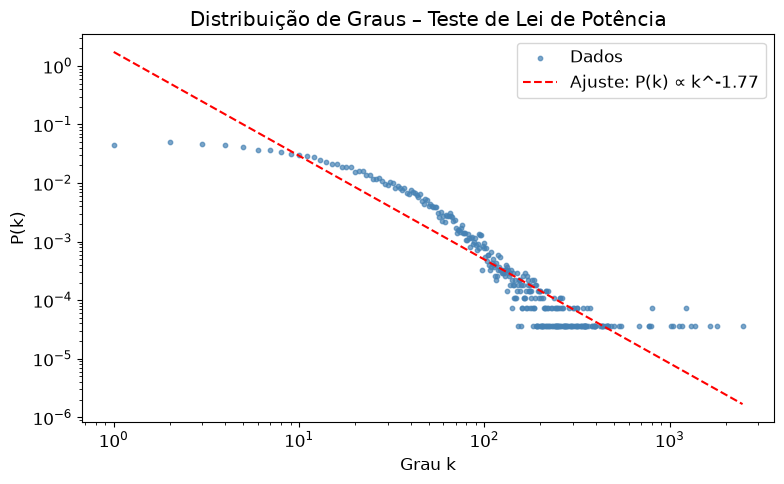

In [32]:
# Ajuste de lei de potência via regressão linear em log-log
# P(k) ~ k^(-gamma)

deg_cnt = Counter(degree_values)
ks = np.array(sorted(deg_cnt.keys()))
ps = np.array([deg_cnt[k]/n_und for k in ks])

# Filtrar grau 0 para log
mask = (ks > 0) & (ps > 0)
log_k = np.log10(ks[mask])
log_p = np.log10(ps[mask])

slope, intercept, r_value, p_value, std_err = stats.linregress(log_k, log_p)

print('=== LEI DE POTÊNCIA ===')
print(f'Expoente γ estimado: {-slope:.4f}')
print(f'R²: {r_value**2:.4f}')
print(f'p-valor: {p_value:.6f}')
print(f'\n→ Distribuição sugere lei de potência? {"SIM" if r_value**2 > 0.8 else "PARCIALMENTE"}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ks[mask], ps[mask], s=10, color='steelblue', alpha=0.7, label='Dados')
x_fit = np.logspace(np.log10(ks[mask].min()), np.log10(ks[mask].max()), 200)
y_fit = 10**intercept * x_fit**slope
ax.plot(x_fit, y_fit, 'r--', label=f'Ajuste: P(k) ∝ k^{slope:.2f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Grau k')
ax.set_ylabel('P(k)')
ax.set_title('Distribuição de Graus – Teste de Lei de Potência')
ax.legend()
plt.tight_layout()
plt.savefig('lei_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

## 26. Robustez do Grafo

In [33]:
def maior_componente_fraction(G_temp):
    """Retorna a fração de nós na maior WCC."""
    if G_temp.number_of_nodes() == 0:
        return 0
    wccs_t = sorted(nx.weakly_connected_components(G_temp), key=len, reverse=True)
    return len(wccs_t[0]) / G_temp.number_of_nodes()

REMOVE_FRAC = 0.05
n_remove = int(n * REMOVE_FRAC)

# ── 26a. Remoção ALEATÓRIA de 5% dos vértices ──────────────────────────────
G_rand_attack = G.copy()
nodes_to_remove_rand = random.sample(list(G_rand_attack.nodes()), n_remove)
G_rand_attack.remove_nodes_from(nodes_to_remove_rand)

frac_rand = maior_componente_fraction(G_rand_attack)
wccs_rand = list(nx.weakly_connected_components(G_rand_attack))

print(f'=== ROBUSTEZ – Remoção Aleatória de {REMOVE_FRAC*100:.0f}% ({n_remove:,} nós) ===')
print(f'  Fração na maior WCC após ataque: {frac_rand:.4f}')
print(f'  Nº de WCCs após ataque: {len(wccs_rand):,}')

# ── 26b. Remoção dos 5% MAIS CENTRAIS (maior grau) ─────────────────────────
G_targeted_attack = G.copy()
nodes_by_degree = sorted(G_targeted_attack.degree(), key=lambda x: x[1], reverse=True)
nodes_to_remove_central = [n_id for n_id, _ in nodes_by_degree[:n_remove]]
G_targeted_attack.remove_nodes_from(nodes_to_remove_central)

frac_targeted = maior_componente_fraction(G_targeted_attack)
wccs_targeted = list(nx.weakly_connected_components(G_targeted_attack))

print(f'\n=== ROBUSTEZ – Remoção dos {REMOVE_FRAC*100:.0f}% mais centrais ({n_remove:,} nós) ===')
print(f'  Fração na maior WCC após ataque: {frac_targeted:.4f}')
print(f'  Nº de WCCs após ataque: {len(wccs_targeted):,}')

print(f'\n→ Conclusão: Ataque direcionado é {"mais" if frac_targeted < frac_rand else "menos"} '
      'destrutivo que ataque aleatório (esperado em redes scale-free).')

=== ROBUSTEZ – Remoção Aleatória de 5% (1,370 nós) ===
  Fração na maior WCC após ataque: 0.9964
  Nº de WCCs após ataque: 71

=== ROBUSTEZ – Remoção dos 5% mais centrais (1,370 nós) ===
  Fração na maior WCC após ataque: 0.9937
  Nº de WCCs após ataque: 127

→ Conclusão: Ataque direcionado é mais destrutivo que ataque aleatório (esperado em redes scale-free).


## 27. Descoberta Mais Interessante

In [34]:
# Top 10 artigos mais citados (maior in-degree)
in_degrees = dict(G.in_degree())
top_cited = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]

print('=== TOP 10 ARTIGOS MAIS CITADOS (maior in-degree) ===')
for rank, (node, deg) in enumerate(top_cited, 1):
    data = G.nodes[node].get('date', 'N/A')
    print(f'  {rank:2d}. Artigo {node} | Citações recebidas: {deg} | Data: {data}')

# Top 10 que mais citam (maior out-degree)
out_degrees = dict(G.out_degree())
top_citing = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

print('\n=== TOP 5 ARTIGOS QUE MAIS CITAM (maior out-degree) ===')
for rank, (node, deg) in enumerate(top_citing, 1):
    print(f'  {rank}. Artigo {node} | Citações feitas: {deg}')

=== TOP 10 ARTIGOS MAIS CITADOS (maior in-degree) ===
   1. Artigo 9711200 | Citações recebidas: 2414 | Data: N/A
   2. Artigo 9802150 | Citações recebidas: 1775 | Data: N/A
   3. Artigo 9802109 | Citações recebidas: 1641 | Data: N/A
   4. Artigo 9407087 | Citações recebidas: 1299 | Data: N/A
   5. Artigo 9610043 | Citações recebidas: 1199 | Data: N/A
   6. Artigo 9510017 | Citações recebidas: 1155 | Data: N/A
   7. Artigo 9908142 | Citações recebidas: 1144 | Data: N/A
   8. Artigo 9503124 | Citações recebidas: 1114 | Data: N/A
   9. Artigo 9906064 | Citações recebidas: 1032 | Data: N/A
  10. Artigo 9408099 | Citações recebidas: 1006 | Data: N/A

=== TOP 5 ARTIGOS QUE MAIS CITAM (maior out-degree) ===
  1. Artigo 9905111 | Citações feitas: 562
  2. Artigo 9710046 | Citações feitas: 359
  3. Artigo 110055 | Citações feitas: 302
  4. Artigo 210157 | Citações feitas: 289
  5. Artigo 101126 | Citações feitas: 274


## 28. Evolução Temporal das Citações

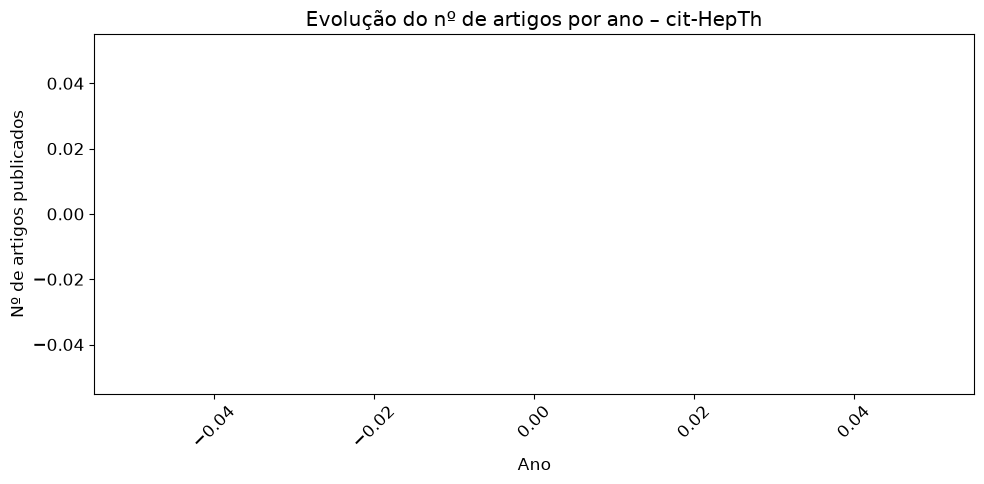

In [35]:
# Distribuição de artigos por ano
years = []
for node in G.nodes():
    date = G.nodes[node].get('date')
    if date:
        try:
            year = int(date[:4])
            years.append(year)
        except:
            pass

year_counts = Counter(years)
year_sorted = sorted(year_counts.items())

plt.figure(figsize=(10, 5))
plt.bar([y for y, _ in year_sorted], [c for _, c in year_sorted], color='steelblue', alpha=0.8)
plt.xlabel('Ano')
plt.ylabel('Nº de artigos publicados')
plt.title('Evolução do nº de artigos por ano – cit-HepTh')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('evolucao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 29. (EXTRA) Modelo Clássico mais Próximo

In [36]:
print('=== QUAL MODELO CLÁSSICO MELHOR DESCREVE O GRAFO? ===')
print()
print('Evidências coletadas:')
print(f'  γ estimado = {-slope:.4f} (lei de potência no grau)')
print(f'  σ (small-world) = {sigma:.4f}')
print(f'  Clustering médio = {avg_clustering:.4f}')
print(f'  Diâmetro ≈ {diameter_estimate}')
print()
print('Modelos clássicos:')
print('  • Erdős-Rényi (ER): baixo clustering, L ≈ log(N), sem hub → NÃO se encaixa')
print('  • Barabási-Albert (BA): lei de potência com γ ≈ 3, hubs, scale-free → CANDIDATO')
print('  • Watts-Strogatz (WS): alto clustering, L curto, SEM lei de potência → PARCIAL')
print()
print('→ Conclusão: O grafo cit-HepTh apresenta características de rede scale-free')
print('  (Barabási-Albert): hubs de citação, distribuição de grau com cauda pesada,')
print('  alta heterogeneidade. Também exibe efeito small-world (σ >> 1).')
print('  Isso é esperado em redes de citação científica reais.')

=== QUAL MODELO CLÁSSICO MELHOR DESCREVE O GRAFO? ===

Evidências coletadas:
  γ estimado = 1.7723 (lei de potência no grau)
  σ (small-world) = 107.9142
  Clustering médio = 0.3139
  Diâmetro ≈ 31

Modelos clássicos:
  • Erdős-Rényi (ER): baixo clustering, L ≈ log(N), sem hub → NÃO se encaixa
  • Barabási-Albert (BA): lei de potência com γ ≈ 3, hubs, scale-free → CANDIDATO
  • Watts-Strogatz (WS): alto clustering, L curto, SEM lei de potência → PARCIAL

→ Conclusão: O grafo cit-HepTh apresenta características de rede scale-free
  (Barabási-Albert): hubs de citação, distribuição de grau com cauda pesada,
  alta heterogeneidade. Também exibe efeito small-world (σ >> 1).
  Isso é esperado em redes de citação científica reais.


---
## 30. Salvar Grafo Tratado

In [37]:
# Salvar lista de adjacência do grafo tratado
nx.write_edgelist(G, 'data/cit_HepTh_tratado.edgelist', data=False)
print('Grafo tratado salvo em: data/cit_HepTh_tratado.edgelist')
print('\nArquivos gerados:')
import glob
for f in sorted(glob.glob('*.png') + glob.glob('*.csv') + glob.glob('data/*.edgelist')):
    print(f'  {f}')

Grafo tratado salvo em: data/cit_HepTh_tratado.edgelist

Arquivos gerados:
  data\cit_HepTh_tratado.edgelist
  distribuicao_graus.png
  evolucao_temporal.png
  lei_potencia.png
  tabela_algoritmos_parte2.csv
  tabela_metricas_parte1.csv
  visualizacao_grafo.png
